In [1]:
# View and modify the working path
import os
from google.colab import drive

# View current working directory
print("Current Working Directory:", os.getcwd())

# Mount Google Drive
drive.mount('/content/gdrive')

# Change working directory to your file position
path = "/content/gdrive/My Drive/BD4H/data"
os.chdir(path)

# Confirm the change
print("Working Directory:", os.getcwd())

Current Working Directory: /content
Mounted at /content/gdrive
Working Directory: /content/gdrive/My Drive/BD4H/data


In [2]:
import pandas as pd

#Read the DIAGNOSES_ICD table and select the admission IDs related to heart failure
ICD_info = pd.read_csv('DIAGNOSES_ICD.csv.gz', usecols=['SUBJECT_ID', 'HADM_ID', 'ICD9_CODE'], compression='gzip')
heart_failure_ICD=['39891', '40201', '40211', '40291', '40401', '40403',\
                   '40411', '40413', '40491', '40493', '4280', '4281',\
                   '42820', '42821', '42822', '42823', '42830', '42831',\
                   '42832', '42833','42840', '42841', '42842', '42843', '4289']
heart_failure_events = ICD_info[ICD_info['ICD9_CODE'].isin(heart_failure_ICD)]
#Unique admission IDs related to heart failure
heart_failure_HADM = heart_failure_events['HADM_ID'].unique()
display(len(heart_failure_HADM))

#Read the ADMISSIONS table and determine the admission and discharge time of the heart failure events
admission_info = pd.read_csv('ADMISSIONS.csv', usecols=['SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'DISCHTIME'],\
                             parse_dates=['ADMITTIME', 'DISCHTIME'])
heart_failure_admittime = admission_info[admission_info['HADM_ID'].isin(heart_failure_HADM)]
#Sort the table by SUBJECT_ID (patient) and admission time
sorted_df=heart_failure_admittime.sort_values(by=['SUBJECT_ID', 'ADMITTIME'])
#Group by SUBJECT_ID and isolate all but the most recent HADM_ID for each group
most_recent_adm = sorted_df.groupby('SUBJECT_ID')['HADM_ID'].tail(1).reset_index(drop=True)
#The remaining HADM_IDs correspond to general heart failure readmissions of each patient.
general_readm = sorted_df.loc[~sorted_df['HADM_ID'].isin(most_recent_adm),'HADM_ID']
display(len(general_readm.unique()))

#Move the admission time upward by one place for each patient
sorted_df['shifted_admittime'] = sorted_df.groupby('SUBJECT_ID')['ADMITTIME'].shift(-1)
#Compute the interval between two successive admissions for each patient
sorted_df['interval'] = sorted_df['shifted_admittime'] - sorted_df['DISCHTIME']
#Isolate the 30-day heart failure readmissions
readm_30d = sorted_df.loc[sorted_df['interval'] <= pd.Timedelta(days=31), 'HADM_ID']
display(len(readm_30d))

14040

3604

969

In [3]:
#Read the NOTEEVENTS table and select the items that are Discharge summary
note_info = pd.read_csv('NOTEEVENTS.csv.gz', usecols=['SUBJECT_ID','HADM_ID','CATEGORY','TEXT'],compression='gzip')
discharge_sum=note_info[note_info['CATEGORY']=='Discharge summary']
#Isolate the Discharge summaries that belong to heart failure admissions
discharge_hf = discharge_sum[discharge_sum['HADM_ID'].isin(heart_failure_HADM)]
#Isolate the admissions that are related to heart failure and have at least a discharge summary
hf_adm_discharge = discharge_hf['HADM_ID'].unique()
display(len(hf_adm_discharge))

gen_readm_discharge = set(general_readm).intersection(set(hf_adm_discharge))
display(len(gen_readm_discharge))

readm_30d_discharge = set(readm_30d).intersection(set(hf_adm_discharge))
display(len(readm_30d_discharge))

13755

3544

963

In [4]:
import nltk
import re
from nltk.corpus import stopwords

#Download stopwords and define the stop words set
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

#Function to clean text: remove stop words and numbers
def clean_text(text):
    # Remove numbers using regex
    text = re.sub(r'\d+', '', text)
    # Split text into words
    words = text.split()
    # Remove stopwords
    words = [word for word in words if word.lower() not in stop_words]
    # Join words back into a cleaned text string
    cleaned_text = ' '.join(words)
    return cleaned_text

# Apply the cleaning function to each row in the 'TEXT' column
discharge_hf['cleaned_text'] = discharge_hf['TEXT'].apply(clean_text)

def text_length(text):
    return len(text.split())  # Count words by splitting by space

#Apply the text_length function to the 'cleaned_text' column
discharge_hf['text_length'] = discharge_hf['cleaned_text'].apply(text_length)

# Group by 'HADM_ID' and find the index of the row with the maximum 'text_length' for each group
idx = discharge_hf.groupby('HADM_ID')['text_length'].idxmax()

# Use .loc to select the rows based on the indices
HADM_len = discharge_hf.loc[idx, ['HADM_ID', 'cleaned_text']]
HADM_len['gen_readm']='negative'
HADM_len.loc[HADM_len['HADM_ID'].isin(gen_readm_discharge),'gen_readm']='positive'
HADM_len['readm_30d']='negative'
HADM_len.loc[HADM_len['HADM_ID'].isin(readm_30d_discharge),'readm_30d']='positive'
HADM_len.to_csv('HADM_readmin.csv', index=False)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
<ipython-input-4-dcf2e71e6047>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  discharge_hf['cleaned_text'] = discharge_hf['TEXT'].apply(clean_text)
<ipython-input-4-dcf2e71e6047>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  discharge_hf['text_length'] = discharge_hf['cleaned_text'].apply(text_length)


In [5]:
import pandas as pd

#Read the csv file and generate gen_readm_df and readm_30d_df
readm = pd.read_csv('HADM_readmin.csv')
gen_readm_df = readm[['HADM_ID', 'cleaned_text', 'gen_readm']]
readm_30d_df = readm[['HADM_ID', 'cleaned_text', 'readm_30d']]

#Under-sampling for gen_readm
gen_positive = gen_readm_df[gen_readm_df['gen_readm'] == 'positive']  # Select positives
gen_negative = gen_readm_df[gen_readm_df['gen_readm'] == 'negative']  # Select negatives

#Randomly sample negative cases to match the number of positives
gen_negative_sampled = gen_negative.sample(n=len(gen_positive), random_state=903965310)

#Concatenate positives and sampled negatives
gen_balanced = pd.concat([gen_positive, gen_negative_sampled])

#Under-sampling for readm_30d
readm_positive = readm_30d_df[readm_30d_df['readm_30d'] == 'positive']  # Select positives
readm_negative = readm_30d_df[readm_30d_df['readm_30d'] == 'negative']  # Select negatives

#Randomly sample negative cases to match the number of positives
readm_negative_sampled = readm_negative.sample(n=len(readm_positive), random_state=903965310)

#Concatenate positives and sampled negatives
readm_balanced = pd.concat([readm_positive, readm_negative_sampled])

#Now both gen_balanced and readm_balanced have equal number of positive and negative samples
display(gen_balanced['gen_readm'].value_counts(), readm_balanced['readm_30d'].value_counts())

,count
gen_readm,
positive,3544
negative,3544


,count
readm_30d,
positive,963
negative,963


In [6]:
pd.set_option('display.max_colwidth', None)

print('Admissions followed by readmissions\n')
print(gen_positive.shape)
display(gen_positive.head(1))

print('--------------------------\n\n')

print('Admissions followed by 30-d readmissions\n')
print(readm_positive.shape)
display(readm_positive.head(1))

Admissions followed by readmissions

(3544, 3)


HADM_ID  \
0  100018.0   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

--------------------------


Admissions followed by 30-d readmissions

(963, 3)


HADM_ID  \
1  100020.0   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [7]:
%%capture
!pip install dspy_ai transformers bitsandbytes

In [ ]:
import dspy
import dspy.utils
import os
import pandas as pd

os.environ["OPENAI_API_KEY"] = 'xxxxxxxxxxxxxxxx'
lm = dspy.LM('openai/gpt-4o-mini')
dspy.configure(lm=lm)

In [9]:
# create signature showing input and output

class GenerateAnswer(dspy.Signature):
    """Answer questions with short factoid answers."""

    context = dspy.InputField(desc="contain relevant facts")
    question = dspy.InputField(desc="multiple unique question")
    answer = dspy.OutputField(desc='''Unique possible answers in JSON format.
                                      Each answer should be a key-value pair with a key length between 1 and 15
                                      characters and a value length between 1 and 10 words.''')

# Create module using dspy module
class QUESTIONANSWER(dspy.Module):
    def __init__(self,question):
        super().__init__()
        self.generate_answer = dspy.ChainOfThought(GenerateAnswer)
        self.question=question

    def forward(self, context):
        question=self.question
        pred = self.generate_answer(context=context, question=question)
        return dspy.Prediction(context=context,answer=pred.answer)

uncompiled_fs=QUESTIONANSWER('''
                             1. Does this patient has heart failure history?
                             2. How bad is this patient's heart failure history?
                             3. why is this patient admitted this time?
                              ''')

In [10]:
# # Run some test
# random5_readm = gen_positive.sample(5, random_state=42)
# text_list = random5_readm['cleaned_text'].tolist()
# print(len(text_list))
# print(text_list[0])

In [11]:
# print(uncompiled_fs(context=text_list[0]).answer)

In [12]:
# import json

# result_json = [json.loads(uncompiled_fs(text).answer)  for text in text_list]
# print(json.dumps(result_json, indent=4))

Prepare df for DSPy complier

In [50]:
# Create readmission training and test sets
readmission_positive = gen_positive
readmission_positive_train = gen_positive.sample(2)
readmission_positive_test = gen_positive.sample(5)

readmission_negative = gen_negative_sampled
readmission_negative_train = gen_negative_sampled.sample(4)
readmission_negative_test = gen_negative_sampled.sample(5)

readmission_train = pd.concat([readmission_positive_train, readmission_negative_train])
readmission_test = pd.concat([readmission_positive_test, readmission_negative_test])


# Create readmission-30d training and test sets
readmission_30d_positive = readm_positive
readmission_30d_positive_train = readm_positive.sample(2)
readmission_30d_positive_test = readm_positive.sample(5)

readmission_30d_negative = readm_negative_sampled
readmission_30d_negative_train = readm_negative_sampled.sample(4)
readmission_30d_negative_test = readm_negative_sampled.sample(5)

readmission_30d_train = pd.concat([readmission_30d_positive_train, readmission_30d_negative_train])
readmission_30d_test = pd.concat([readmission_30d_positive_test, readmission_30d_negative_test])

print(readmission_train.shape, readmission_test.shape)
print(readmission_30d_train.shape, readmission_30d_test.shape)


(6, 3) (10, 3)
(6, 3) (10, 3)


In [14]:
# Train pipeline and do initial evaluation
from dspy.teleprompt import BootstrapFewShot
from dspy.evaluate.evaluate import Evaluate

# readmission
  #cleaned_text	gen_readm
# readmission_30d
  #cleaned_text	readm_30d

General Readmission

In [51]:
# set up training dataset and validation dataset for readmission sets
readmission_train_results = list(readmission_train['gen_readm'])
readmission_train_contents=list(readmission_train['cleaned_text'])
print(len(readmission_train_results),len(readmission_train_contents))

readmission_test_results = list(readmission_test['gen_readm'])
readmission_test_contents = list(readmission_test['cleaned_text'])
print(len(readmission_test_results),len(readmission_test_contents))

readmission_train_list=[dspy.Example(context=content, answer=result) for content, result in zip(readmission_train_contents, readmission_train_results)]
readmission_test_list=[dspy.Example(context=content, answer=result) for content, result in zip(readmission_test_contents, readmission_test_results)]

trainset=readmission_train_list
devset=readmission_test_list

# 'body' field is the input. 'pred_json'are labels and/or metadata.
trainset = [x.with_inputs('context') for x in trainset]
devset = [x.with_inputs('context') for x in devset]

print(len(trainset),len(devset))

6 6
10 10
6 10


In [19]:
# create signature showing input and output

class GenerateAnswer(dspy.Signature):
    """Answer questions with short factoid answers."""

    context = dspy.InputField(desc="A detailed section of the patient's doctor's notes, including prior diagnoses, treatment history, and any predictive risk factors for readmission.")
    question = dspy.InputField(desc="A short question.")
    answer = dspy.OutputField(desc="A brief prediction on whether the readmission is 'positive' (likely) or 'negative' (unlikely), and you can slightly more favor negative when you are not sure of the prediction.")

# Create module using dspy module
class QUESTIONANSWER(dspy.Module):
    def __init__(self,question):
        super().__init__()
        self.generate_answer = dspy.ChainOfThought(GenerateAnswer)
        self.question=question

    def forward(self, context):
        question=self.question
        pred = self.generate_answer(context=context, question=question)
        return dspy.Prediction(context=context,answer=pred.answer)

uncompiled=QUESTIONANSWER('''
                             Will this patient come back for readmission?
                              ''')

In [20]:
# Validation logic: check that the predicted answer is correct using 'exact_match'
# def validate_answer(example, pred, trace=None):
#     answer_EM = dspy.evaluate.answer_exact_match(example, pred)
#     return answer_EM

def validate_answer(example, pred, trace=None):
    return example.answer.lower() == pred.answer.lower()

teleprompter = BootstrapFewShot(metric=validate_answer)

# Compile
compiled = teleprompter.compile(uncompiled, trainset=trainset)

evaluation = Evaluate(devset=devset, num_threads=1, display_progress=True, display_table= True,return_outputs= True)

# below code will check the accuracy code before optimizing
prev_score, outputs_prev = evaluation(uncompiled, metric=validate_answer)

# get the accuracy after optimizing
improved_score, outputs_improved = evaluation(compiled, metric=validate_answer)

100%|██████████| 6/6 [00:16<00:00,  2.70s/it]


Bootstrapped 3 full traces after 5 examples for up to 1 rounds, amounting to 6 attempts.
Average Metric: 5 / 10  (50.0): 100%|██████████| 10/10 [00:15<00:00,  1.59s/it]

2024/11/06 22:50:40 INFO dspy.evaluate.evaluate: Average Metric: 5 / 10 (50.0%)


,example_context,example_answer,pred_context,pred_answer,validate_answer
0,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Penicillins Attending:[**Last Name (NamePattern) **] Chief Complaint: nausea/vomiting Major Surgical Invasive...,positive,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Penicillins Attending:[**Last Name (NamePattern) **] Chief Complaint: nausea/vomiting Major Surgical Invasive...,negative,
1,"Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: HISTORY PRESENT ILLNESS: patient -year-old female complicated past medical history including Takayasu arteritis,...",positive,"Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: HISTORY PRESENT ILLNESS: patient -year-old female complicated past medical history including Takayasu arteritis,...",negative,
2,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Celecoxib Attending:[**First Name (LF) **] Chief Complaint: thrombocytopenia Major Surgical Invasive...,positive,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Celecoxib Attending:[**First Name (LF) **] Chief Complaint: thrombocytopenia Major Surgical Invasive...,negative,
3,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Sulfa (Sulfonamide Antibiotics) / Vioxx / Celebrex / Lasix Attending:[**First Name...,positive,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Sulfa (Sulfonamide Antibiotics) / Vioxx / Celebrex / Lasix Attending:[**First Name...,negative,
4,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Patient recorded Known Allergies Drugs Attending:[**First Name (LF) **] Chief Complaint: Transferred...,positive,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Patient recorded Known Allergies Drugs Attending:[**First Name (LF) **] Chief Complaint: Transferred...,negative,
5,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Penicillins Attending:[**First Name (LF) **] Chief Complaint: Lethargy Major Surgical Invasive...,negative,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Penicillins Attending:[**First Name (LF) **] Chief Complaint: Lethargy Major Surgical Invasive...,negative,✔️ [True]
6,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: CARDIOTHORACIC Allergies: Levaquin / Lisinopril / Metoprolol / Fentanyl / Hydromorphone Attending:[**First Name...,negative,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: CARDIOTHORACIC Allergies: Levaquin / Lisinopril / Metoprolol / Fentanyl / Hydromorphone Attending:[**First Name...,negative,✔️ [True]
7,"Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Zestril / Lopid / Shellfish / Radioactive Diagnostics, General Classif Attending:[**First Name...",negative,"Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Zestril / Lopid / Shellfish / Radioactive Diagnostics, General Classif Attending:[**First Name...",negative,✔️ [True]
8,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: [**Year ( digits) **] Allergies: Penicillins / Amiodarone Attending:[**First Name (LF) **] Chief Complaint:...,negative,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: [**Year ( digits) **] Allergies: Penicillins / Amiodarone Attending:[**First Name (LF) **] Chief Complaint:...,negative,✔️ [True]
9,Admissio

Average Metric: 6 / 10  (60.0): 100%|██████████| 10/10 [00:30<00:00,  3.08s/it]

2024/11/06 22:51:11 INFO dspy.evaluate.evaluate: Average Metric: 6 / 10 (60.0%)


,example_context,example_answer,pred_context,pred_answer,validate_answer
0,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Penicillins Attending:[**Last Name (NamePattern) **] Chief Complaint: nausea/vomiting Major Surgical Invasive...,positive,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Penicillins Attending:[**Last Name (NamePattern) **] Chief Complaint: nausea/vomiting Major Surgical Invasive...,positive,✔️ [True]
1,"Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: HISTORY PRESENT ILLNESS: patient -year-old female complicated past medical history including Takayasu arteritis,...",positive,"Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: HISTORY PRESENT ILLNESS: patient -year-old female complicated past medical history including Takayasu arteritis,...",positive,✔️ [True]
2,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Celecoxib Attending:[**First Name (LF) **] Chief Complaint: thrombocytopenia Major Surgical Invasive...,positive,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Celecoxib Attending:[**First Name (LF) **] Chief Complaint: thrombocytopenia Major Surgical Invasive...,positive,✔️ [True]
3,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Sulfa (Sulfonamide Antibiotics) / Vioxx / Celebrex / Lasix Attending:[**First Name...,positive,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Sulfa (Sulfonamide Antibiotics) / Vioxx / Celebrex / Lasix Attending:[**First Name...,positive,✔️ [True]
4,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Patient recorded Known Allergies Drugs Attending:[**First Name (LF) **] Chief Complaint: Transferred...,positive,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Patient recorded Known Allergies Drugs Attending:[**First Name (LF) **] Chief Complaint: Transferred...,positive,✔️ [True]
5,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Penicillins Attending:[**First Name (LF) **] Chief Complaint: Lethargy Major Surgical Invasive...,negative,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Penicillins Attending:[**First Name (LF) **] Chief Complaint: Lethargy Major Surgical Invasive...,negative,✔️ [True]
6,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: CARDIOTHORACIC Allergies: Levaquin / Lisinopril / Metoprolol / Fentanyl / Hydromorphone Attending:[**First Name...,negative,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: CARDIOTHORACIC Allergies: Levaquin / Lisinopril / Metoprolol / Fentanyl / Hydromorphone Attending:[**First Name...,positive,
7,"Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Zestril / Lopid / Shellfish / Radioactive Diagnostics, General Classif Attending:[**First Name...",negative,"Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Zestril / Lopid / Shellfish / Radioactive Diagnostics, General Classif Attending:[**First Name...",positive,
8,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: [**Year ( digits) **] Allergies: Penicillins / Amiodarone Attending:[**First Name (LF) **] Chief Complaint:...,negative,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: [**Year ( digits) **] Allergies: Penicillins / Amiodarone Attending:[**First Name (LF) **] Chief Complaint:...,po

In [21]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

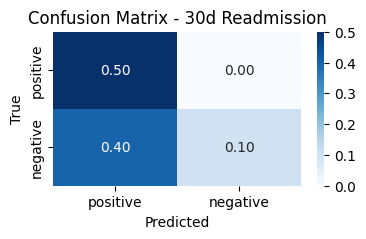



      Metric     Value
0   Accuracy  0.600000
1  Precision  0.555556
2     Recall  1.000000
3   F1 Score  0.714286


In [22]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

true_label=[]
predicted_label=[]

for content in outputs_improved:
    true_label.append(content[0]['answer'])
    predicted_label.append(content[1]['answer'])

conf_matrix = confusion_matrix(true_label, predicted_label, labels=['positive', 'negative'])
conf_matrix_percentages = conf_matrix.astype('float') / conf_matrix.sum()

# Create a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(conf_matrix_percentages, annot=True, fmt='.2f', cmap='Blues', xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - 30d Readmission')
plt.show()
print('\n')

# Calculate metrics
accuracy = accuracy_score(true_label, predicted_label)
precision = precision_score(true_label, predicted_label, pos_label='positive')
recall = recall_score(true_label, predicted_label, pos_label='positive')
f1 = f1_score(true_label, predicted_label, pos_label='positive')

# Create a DataFrame to store metrics
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

print(metrics_df)

30-day Readmission

In [46]:
# set up training dataset and validation dataset for readmission sets
readmission_train_results = list(readmission_30d_train['readm_30d'])
readmission_train_contents=list(readmission_30d_train['cleaned_text'])
print(len(readmission_train_results),len(readmission_train_contents))

readmission_test_results = list(readmission_30d_test['readm_30d'])
readmission_test_contents = list(readmission_30d_test['cleaned_text'])
print(len(readmission_test_results),len(readmission_test_contents))

readmission_train_list=[dspy.Example(context=content, answer=result) for content, result in zip(readmission_train_contents, readmission_train_results)]
readmission_test_list=[dspy.Example(context=content, answer=result) for content, result in zip(readmission_test_contents, readmission_test_results)]

trainset=readmission_train_list
devset=readmission_test_list

# 'body' field is the input. 'pred_json'are labels and/or metadata.
trainset = [x.with_inputs('context') for x in trainset]
devset = [x.with_inputs('context') for x in devset]

print(len(trainset),len(devset))

6 6
10 10
6 10


In [26]:
# create signature showing input and output

class GenerateAnswer(dspy.Signature):
    """Answer questions with short factoid answers."""

    context = dspy.InputField(desc="A detailed section of the patient's doctor's notes, including prior diagnoses, treatment history, and any predictive risk factors for readmission.")
    question = dspy.InputField(desc="A short question.")
    answer = dspy.OutputField(desc="A brief prediction on whether the readmission within 30 days is 'positive' (likely) or 'negative' (unlikely), and you can favor negative when you are not entirely sure of the prediction.")

# Create module using dspy module
class QUESTIONANSWER(dspy.Module):
    def __init__(self,question):
        super().__init__()
        self.generate_answer = dspy.ChainOfThought(GenerateAnswer)
        self.question=question

    def forward(self, context):
        question=self.question
        pred = self.generate_answer(context=context, question=question)
        return dspy.Prediction(context=context,answer=pred.answer)

uncompiled=QUESTIONANSWER('''
                             Will this patient come back within 30 days?
                              ''')

In [27]:
# Validation logic: check that the predicted answer is correct using 'exact_match'
# def validate_answer(example, pred, trace=None):
#     answer_EM = dspy.evaluate.answer_exact_match(example, pred)
#     return answer_EM

def validate_answer(example, pred, trace=None):
    return example.answer.lower() == pred.answer.lower()

teleprompter = BootstrapFewShot(metric=validate_answer)

# Compile
compiled = teleprompter.compile(uncompiled, trainset=trainset)

evaluation = Evaluate(devset=devset, num_threads=1, display_progress=True, display_table= True,return_outputs= True)

# below code will check the accuracy code before optimizing
prev_score, outputs_prev = evaluation(uncompiled, metric=validate_answer)

# get the accuracy after optimizing
improved_score, outputs_improved = evaluation(compiled, metric=validate_answer)

 83%|████████▎ | 5/6 [00:11<00:02,  2.37s/it]


Bootstrapped 4 full traces after 5 examples for up to 1 rounds, amounting to 5 attempts.
Average Metric: 4 / 10  (40.0): 100%|██████████| 10/10 [00:23<00:00,  2.34s/it]

2024/11/06 22:53:01 INFO dspy.evaluate.evaluate: Average Metric: 4 / 10 (40.0%)


,example_context,example_answer,pred_context,pred_answer,validate_answer
0,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Penicillins Attending:[**First Name (LF) **] Chief Complaint: Delirium. Major Surgical Invasive Procedure:...,positive,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Penicillins Attending:[**First Name (LF) **] Chief Complaint: Delirium. Major Surgical Invasive Procedure:...,negative,
1,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Known Allergies / Adverse Drug Reactions Attending:[**First Name (LF) **] Chief Complaint:...,positive,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Known Allergies / Adverse Drug Reactions Attending:[**First Name (LF) **] Chief Complaint:...,negative,
2,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Ciprofloxacin / Zometa / Keflex / Tetracycline / erythromycin / Iodine...,positive,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Ciprofloxacin / Zometa / Keflex / Tetracycline / erythromycin / Iodine...,negative,
3,Admission Date: [**--**] Discharge Date: [**--**] Service: CARDIOTHORACIC Allergies: Patient recorded Known Allergies Drugs Attending:[**First Name (LF) **] Chief Complaint: recurrent right pleural effsuion admitted...,positive,Admission Date: [**--**] Discharge Date: [**--**] Service: CARDIOTHORACIC Allergies: Patient recorded Known Allergies Drugs Attending:[**First Name (LF) **] Chief Complaint: recurrent right pleural effsuion admitted...,negative,
4,"Admission Date: [**--**] Discharge Date: [**--**] Service: Medicine HISTORY PRESENT ILLNESS: patient year old white female history severe scoliosis, osteoporosis, hypertension, status post T-T fusion...",positive,"Admission Date: [**--**] Discharge Date: [**--**] Service: Medicine HISTORY PRESENT ILLNESS: patient year old white female history severe scoliosis, osteoporosis, hypertension, status post T-T fusion...",negative,
5,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE HISTORY PRESENT ILLNESS: patient year old female nursing home recently discharged [**Hospital...,negative,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE HISTORY PRESENT ILLNESS: patient year old female nursing home recently discharged [**Hospital...,positive,
6,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Codeine / Erythromycin Base / Sulfa (Sulfonamides) / Prednisone / Percocet...,negative,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Codeine / Erythromycin Base / Sulfa (Sulfonamides) / Prednisone / Percocet...,negative,✔️ [True]
7,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Patient recorded Known Allergies Drugs Attending:[**First Name (LF) **] Chief Complaint: Chest...,negative,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Patient recorded Known Allergies Drugs Attending:[**First Name (LF) **] Chief Complaint: Chest...,negative,✔️ [True]
8,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: SURGERY Allergies: Sulfa (Sulfonamides) / Iodine Containing Agents Classifier / Bee Sting Kit Attending:[**First...,negative,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: SURGERY Allergies: Sulfa (Sulfonamides) / Iodine Containing Agents Classifier / Bee Sting Kit Attending:[**First...,negative,✔️ [True]
9,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: 

Average Metric: 5 / 10  (50.0): 100%|██████████| 10/10 [00:28<00:00,  2.84s/it]

2024/11/06 22:53:30 INFO dspy.evaluate.evaluate: Average Metric: 5 / 10 (50.0%)


,example_context,example_answer,pred_context,pred_answer,validate_answer
0,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Penicillins Attending:[**First Name (LF) **] Chief Complaint: Delirium. Major Surgical Invasive Procedure:...,positive,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Penicillins Attending:[**First Name (LF) **] Chief Complaint: Delirium. Major Surgical Invasive Procedure:...,positive,✔️ [True]
1,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Known Allergies / Adverse Drug Reactions Attending:[**First Name (LF) **] Chief Complaint:...,positive,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Known Allergies / Adverse Drug Reactions Attending:[**First Name (LF) **] Chief Complaint:...,positive,✔️ [True]
2,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Ciprofloxacin / Zometa / Keflex / Tetracycline / erythromycin / Iodine...,positive,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Ciprofloxacin / Zometa / Keflex / Tetracycline / erythromycin / Iodine...,positive,✔️ [True]
3,Admission Date: [**--**] Discharge Date: [**--**] Service: CARDIOTHORACIC Allergies: Patient recorded Known Allergies Drugs Attending:[**First Name (LF) **] Chief Complaint: recurrent right pleural effsuion admitted...,positive,Admission Date: [**--**] Discharge Date: [**--**] Service: CARDIOTHORACIC Allergies: Patient recorded Known Allergies Drugs Attending:[**First Name (LF) **] Chief Complaint: recurrent right pleural effsuion admitted...,positive,✔️ [True]
4,"Admission Date: [**--**] Discharge Date: [**--**] Service: Medicine HISTORY PRESENT ILLNESS: patient year old white female history severe scoliosis, osteoporosis, hypertension, status post T-T fusion...",positive,"Admission Date: [**--**] Discharge Date: [**--**] Service: Medicine HISTORY PRESENT ILLNESS: patient year old white female history severe scoliosis, osteoporosis, hypertension, status post T-T fusion...",positive,✔️ [True]
5,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE HISTORY PRESENT ILLNESS: patient year old female nursing home recently discharged [**Hospital...,negative,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE HISTORY PRESENT ILLNESS: patient year old female nursing home recently discharged [**Hospital...,positive,
6,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Codeine / Erythromycin Base / Sulfa (Sulfonamides) / Prednisone / Percocet...,negative,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: MEDICINE Allergies: Codeine / Erythromycin Base / Sulfa (Sulfonamides) / Prednisone / Percocet...,positive,
7,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Patient recorded Known Allergies Drugs Attending:[**First Name (LF) **] Chief Complaint: Chest...,negative,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: MEDICINE Allergies: Patient recorded Known Allergies Drugs Attending:[**First Name (LF) **] Chief Complaint: Chest...,positive,
8,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: SURGERY Allergies: Sulfa (Sulfonamides) / Iodine Containing Agents Classifier / Bee Sting Kit Attending:[**First...,negative,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: Service: SURGERY Allergies: Sulfa (Sulfonamides) / Iodine Containing Agents Classifier / Bee Sting Kit Attending:[**First...,positive,
9,Admission Date: [**--**] Discharge Date: [**--**] Date Birth: [**--**] Sex: F Service: ME

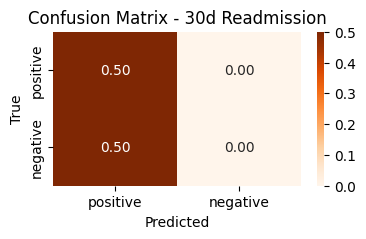



      Metric     Value
0   Accuracy  0.500000
1  Precision  0.500000
2     Recall  1.000000
3   F1 Score  0.666667


In [28]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

true_label=[]
predicted_label=[]

for content in outputs_improved:
    true_label.append(content[0]['answer'])
    predicted_label.append(content[1]['answer'])

conf_matrix = confusion_matrix(true_label, predicted_label, labels=['positive', 'negative'])
conf_matrix_percentages = conf_matrix.astype('float') / conf_matrix.sum()

# Create a heatmap
plt.figure(figsize=(4, 2))
sns.heatmap(conf_matrix_percentages, annot=True, fmt='.2f', cmap='Oranges', xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - 30d Readmission')
plt.show()
print('\n')

# Calculate metrics
accuracy = accuracy_score(true_label, predicted_label)
precision = precision_score(true_label, predicted_label, pos_label='positive')
recall = recall_score(true_label, predicted_label, pos_label='positive')
f1 = f1_score(true_label, predicted_label, pos_label='positive')

# Create a DataFrame to store metrics
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

print(metrics_df)

# Use Lanchain *instead*

In [21]:
%%capture
!pip install langchain_community langchain-openai

In [52]:
import pandas as pd
from langchain.prompts import FewShotPromptTemplate, PromptTemplate
from langchain.chains import LLMChain
from langchain_openai import ChatOpenAI

In [53]:
# Initialize the OpenAI GPT-4 mini model with LangChain
llm = ChatOpenAI(model_name="gpt-4o-mini")

# Load examples for training
readmission_train = pd.concat([readmission_positive_train, readmission_negative_train])
readmission_test = pd.concat([readmission_positive_test, readmission_negative_test])

readmission_30d_train = pd.concat([readmission_30d_positive_train, readmission_30d_negative_train])
readmission_30d_test = pd.concat([readmission_30d_positive_test, readmission_30d_negative_test])

print(readmission_train.shape, readmission_test.shape)
print(readmission_30d_train.shape, readmission_30d_test.shape)

# Convert DataFrame rows to few-shot examples
few_shot_examples_readmission = [
    {"clinical_notes": row["cleaned_text"], "prediction": row["gen_readm"]}
    for _, row in readmission_train.iterrows()
]

few_shot_examples_readmission_30d = [
    {"clinical_notes": row["cleaned_text"], "prediction": row["readm_30d"]}
    for _, row in readmission_30d_train.iterrows()
]

# Format examples for the prompt
formatted_examples_readmission = "\n".join([
    f"Clinical Notes: {ex['clinical_notes']}\nPrediction: {ex['prediction']}"
    for ex in few_shot_examples_readmission
])

formatted_examples_readmission_30d = "\n".join([
    f"Clinical Notes: {ex['clinical_notes']}\nPrediction: {ex['prediction']}"
    for ex in few_shot_examples_readmission_30d
])

(6, 3) (10, 3)
(6, 3) (10, 3)


In [54]:
# Define a template for each example (one-shot format within few-shot structure)
example_prompt = PromptTemplate(
    input_variables=["clinical_notes", "prediction"],
    template="Clinical Notes: {clinical_notes}\nPrediction: {prediction}\n"
)

# Define prefix and suffix for FewShotPromptTemplate
prefix = """
Given the clinical notes, predict if the patient will be readmitted.

Examples:
"""
suffix = """
For each clinical note, follow these steps:
1. **Chain of Thought**: Analyze the clinical notes in a detailed, logical way. Consider patient history, symptoms, any recent treatments, and potential reasons for or against readmission.
2. **ReAct**: Reflect on each part of your thought process, actively identifying any factors that could suggest the patient might *not* need readmission.
3. **Final Prediction**: Based on the reasoning and reflection, provide a final prediction on readmission likelihood.

Clinical Notes: {clinical_notes}
Thought Process (Chain of Thought and ReAct):
"""


# Define the FewShotPromptTemplate using the example prompt, prefix, and suffix
prompt = FewShotPromptTemplate(
    examples=few_shot_examples_readmission,
    example_prompt=example_prompt,
    prefix=prefix,
    suffix=suffix,
    input_variables=["clinical_notes"]
)

# Create an LLMChain for predictions with chain of thought and ReAct reasoning
chain_of_thought_chain = LLMChain(llm=llm, prompt=prompt)

# Function to predict readmission with CoT and ReAct reasoning
def predict_with_cot_react_reasoning(clinical_notes):
    prediction = chain_of_thought_chain.run({"clinical_notes": clinical_notes, "examples": formatted_examples_readmission})
    return prediction


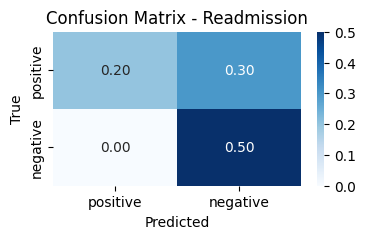



      Metric     Value
0   Accuracy  0.700000
1  Precision  1.000000
2     Recall  0.400000
3   F1 Score  0.571429


In [55]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Function to make predictions on test data and calculate metrics
def evaluate_model(test_data):
    true_labels = test_data["gen_readm"]
    predictions = []

    for clinical_notes in test_data["cleaned_text"]:
        # Generate prediction using the LangChain pipeline with CoT and ReAct reasoning
        prediction = predict_with_cot_react_reasoning(clinical_notes)

        # Extract the final prediction from the model response
        if "positive" in prediction:
            predictions.append("positive")
        else:
            predictions.append("negative")


    # Calculate metrics
    accuracy = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, pos_label="positive")
    recall = recall_score(true_labels, predictions, pos_label="positive")
    f1 = f1_score(true_labels, predictions, pos_label="positive")
    conf_matrix = confusion_matrix(true_labels, predictions, labels=["positive", "negative"])
    conf_matrix_percentages = conf_matrix.astype('float') / conf_matrix.sum()

    # Create a heatmap
    plt.figure(figsize=(4, 2))
    sns.heatmap(conf_matrix_percentages, annot=True, fmt='.2f', cmap='Blues', xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - Readmission')
    plt.show()
    print('\n')

    # Create a DataFrame to store metrics
    metrics_df = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
        "Value": [accuracy, precision, recall, f1]
    })

    print(metrics_df)

# Run evaluation
evaluate_model(readmission_test)


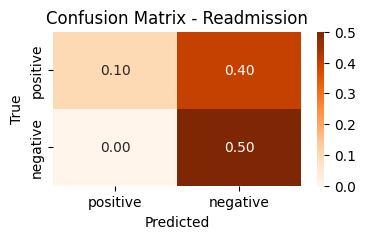



      Metric     Value
0   Accuracy  0.600000
1  Precision  1.000000
2     Recall  0.200000
3   F1 Score  0.333333


In [58]:
# Define a template for each example (one-shot format within few-shot structure)
example_prompt = PromptTemplate(
    input_variables=["clinical_notes", "prediction"],
    template="Clinical Notes: {clinical_notes}\nPrediction: {prediction}\n"
)

# Define prefix and suffix for FewShotPromptTemplate
prefix = """
Given the clinical notes, predict if the patient will be readmitted within 30 days.

Examples:
"""
suffix = """
For each clinical note, follow these steps:
1. **Chain of Thought**: Analyze the clinical notes in a detailed, logical way. Consider patient history, symptoms, any recent treatments, and potential reasons for or against readmission within 30 days.
2. **ReAct**: Reflect on each part of your thought process, actively identifying any factors that could suggest the patient might *not* need readmission.
3. **Final Prediction**: Based on the reasoning and reflection, provide a final prediction on readmission likelihood within 30 days.

Clinical Notes: {clinical_notes}
Thought Process (Chain of Thought and ReAct):
"""


# Define the FewShotPromptTemplate using the example prompt, prefix, and suffix
prompt = FewShotPromptTemplate(
    examples=few_shot_examples_readmission_30d,
    example_prompt=example_prompt,
    prefix=prefix,
    suffix=suffix,
    input_variables=["clinical_notes"]
)

# Create an LLMChain for predictions with chain of thought and ReAct reasoning
chain_of_thought_chain = LLMChain(llm=llm, prompt=prompt)

# Function to predict readmission with CoT and ReAct reasoning
def predict_with_cot_react_reasoning(clinical_notes):
    prediction = chain_of_thought_chain.run({"clinical_notes": clinical_notes, "examples": formatted_examples_readmission_30d})
    return prediction



# Function to make predictions on test data and calculate metrics
def evaluate_model(test_data):
    true_labels = test_data["readm_30d"]
    predictions = []

    for clinical_notes in test_data["cleaned_text"]:
        # Generate prediction using the LangChain pipeline with CoT and ReAct reasoning
        prediction = predict_with_cot_react_reasoning(clinical_notes)

        # Extract the final prediction from the model response
        if "positive" in prediction:
            predictions.append("positive")
        else:
            predictions.append("negative")


    # Calculate metrics
    accuracy = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, pos_label="positive")
    recall = recall_score(true_labels, predictions, pos_label="positive")
    f1 = f1_score(true_labels, predictions, pos_label="positive")
    conf_matrix = confusion_matrix(true_labels, predictions, labels=["positive", "negative"])
    conf_matrix_percentages = conf_matrix.astype('float') / conf_matrix.sum()

    # Create a heatmap
    plt.figure(figsize=(4, 2))
    sns.heatmap(conf_matrix_percentages, annot=True, fmt='.2f', cmap='Oranges', xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - Readmission')
    plt.show()
    print('\n')

    # Create a DataFrame to store metrics
    metrics_df = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
        "Value": [accuracy, precision, recall, f1]
    })

    print(metrics_df)

# Run evaluation
evaluate_model(readmission_30d_test)
